In [1]:
# %% [1] Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    print(f"{model_name} -> Acc: {acc:.4f} | F1: {f1:.4f}")

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")

In [4]:
df.columns = df.columns.str.strip()

print("Data Head:")
print(df.head())

Data Head:
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000  

In [5]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Loan Status')

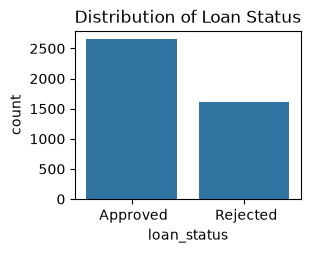

In [6]:
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')

Text(0.5, 1.0, 'Distribution of Loan Status')

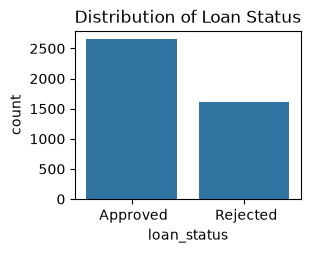

In [7]:
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')

Text(0.5, 1.0, 'CIBIL Score vs Loan Status')

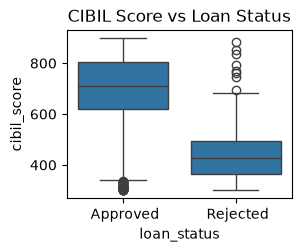

In [8]:
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('CIBIL Score vs Loan Status')

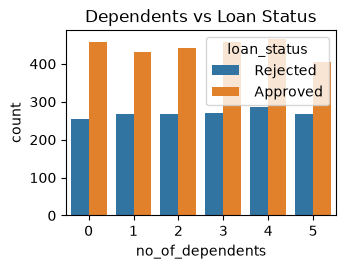

In [9]:
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='no_of_dependents', hue='loan_status')
plt.title('Dependents vs Loan Status')

plt.tight_layout()
plt.show()

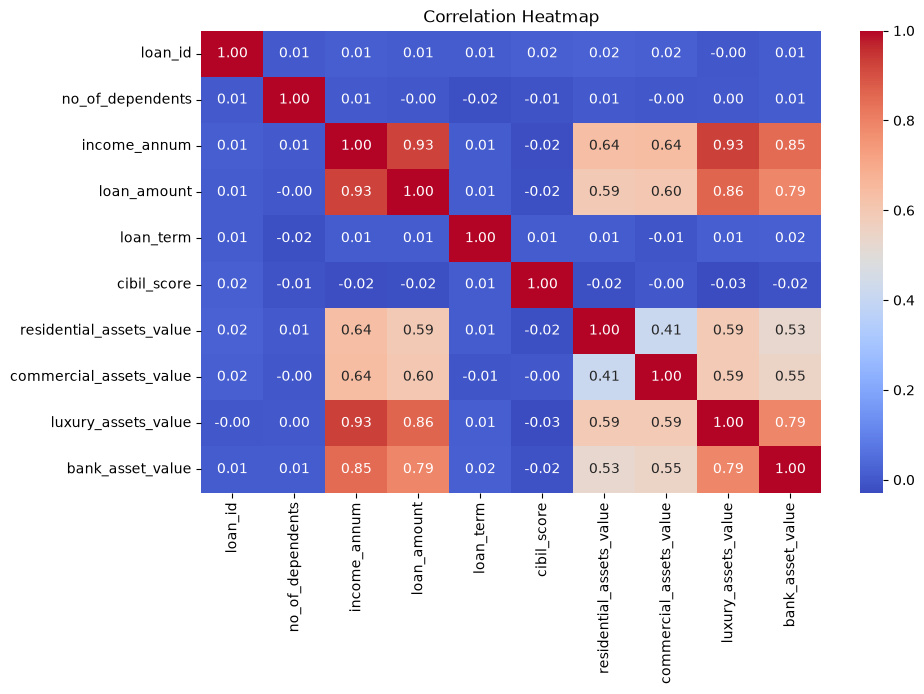

In [10]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

C:\Users\DELL\AppData\Local\Temp\ipykernel_9296\3550401064.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [12]:
if 'loan_id' in df.columns:
    X = df.drop(columns=['loan_id', 'loan_status'])
else:
    X = df.drop(columns=['loan_status'])

y = df['loan_status']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

In [18]:
# %% [4] Logistic Regression (Normal, Ridge, Lasso)
# 1. Normal Logistic Regression (Penalty None)
log_reg_normal = LogisticRegression(penalty=None, random_state=42, max_iter=1000)
log_reg_normal.fit(X_train_scaled, y_train)
y_pred = log_reg_normal.predict(X_test_scaled)
log_reg_normal = LogisticRegression(penalty=None, random_state=42, max_iter=1000)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [23]:
# 2. Ridge Logistic Regression (L2)
log_reg_ridge = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
log_reg_ridge.fit(X_train_scaled, y_train)
y_pred = log_reg_ridge.predict(X_test_scaled)

# تقييم النموذج و اضافة النتائج
evaluate_model('Logistic Regression (Ridge)', y_test, y_pred)

Logistic Regression (Ridge) -> Acc: 0.9227 | F1: 0.9224


In [24]:
import pandas as pd
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Ridge),0.922717,0.92254,0.922717,0.922363


In [25]:
# 3. Lasso Logistic Regression (L1 Penalty)
log_reg_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42, max_iter=1000)
log_reg_lasso.fit(X_train_scaled, y_train)
y_pred = log_reg_lasso.predict(X_test_scaled)
evaluate_model('Logistic Regression (Lasso)', y_test, y_pred)

Logistic Regression (Lasso) -> Acc: 0.9251 | F1: 0.9247


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [26]:
# %% [5] Decision Tree Classifier (Before & After Grid Search)
# 1. Before Grid Search
dt_before = DecisionTreeClassifier(random_state=42)
dt_before.fit(X_train, y_train)
y_pred = dt_before.predict(X_test)
evaluate_model('Decision Tree (Before Grid Search)', y_test, y_pred)

Decision Tree (Before Grid Search) -> Acc: 0.9719 | F1: 0.9718


In [27]:
# 2. After Grid Search
dt_params = {
    'max_depth': [3, 5, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
y_pred = dt_grid.best_estimator_.predict(X_test)
evaluate_model('Decision Tree (After Grid Search)', y_test, y_pred)

Decision Tree (After Grid Search) -> Acc: 0.9778 | F1: 0.9777


In [28]:
# %% [6] Random Forest Classifier (Before & After Grid Search)
# 1. Before Grid Search
rf_before = RandomForestClassifier(random_state=42)
rf_before.fit(X_train, y_train)
y_pred = rf_before.predict(X_test)
evaluate_model('Random Forest (Before Grid Search)', y_test, y_pred)

Random Forest (Before Grid Search) -> Acc: 0.9836 | F1: 0.9836


In [29]:
# 2. After Grid Search
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
y_pred = rf_grid.best_estimator_.predict(X_test)
evaluate_model('Random Forest (After Grid Search)', y_test, y_pred)

Random Forest (After Grid Search) -> Acc: 0.9836 | F1: 0.9836


In [30]:
# %% [7] Results Data Frame with 7 rows
results_df = pd.DataFrame(results)
print("\n=== Final Model Comparison (7 Models) ===")
print(results_df)


=== Final Model Comparison (7 Models) ===
                                Model  Accuracy  Precision    Recall  F1-Score
0         Logistic Regression (Ridge)  0.922717   0.922540  0.922717  0.922363
1         Logistic Regression (Lasso)  0.925059   0.924905  0.925059  0.924716
2  Decision Tree (Before Grid Search)  0.971897   0.971937  0.971897  0.971826
3   Decision Tree (After Grid Search)  0.977752   0.977857  0.977752  0.977688
4  Random Forest (Before Grid Search)  0.983607   0.983709  0.983607  0.983565
5   Random Forest (After Grid Search)  0.983607   0.983709  0.983607  0.983565
